<font size="6">**Introduzione a PyTorch**</font><br>
> *Copyright Antonio Piemontese 2025* (inspired to Sebastian Raschka's work).

---
**Legenda delle icone (standard) usate nel notebook**:<br>

👉 punto di attenzione, il "succo"<br>
📌 nota / inizio di una nota<br>
📦 punto elenco importante<br>
📊 dati/numeri<br>
🔹 punto elenco normale<br>
⭐ punto elenco importante<br>
✅ punto risolto, positivo<br>
❌ punto negativo, da evitare<br>
⚠️ attenzione, warning, allarme<br>
💡 idea chiave<br>
🧠 idea intuitiva<br>
📝 sintesi / bottom-line<br>
⟶ conseguenza, effetto, passo successivo

# Cosa è PyTorch

E' la libreria di Deep Learning in Python oggi più usata, [questo il suo sito](https://pytorch.org/), vedi [qui in generale](https://en.wikipedia.org/wiki/PyTorch). E' open-source.<br>

Le <u>ragioni</u> della popolarità di PyTorch sono **l'interfaccia user-friendly ed efficiente** ed il giusto **equilibrio tra le funzionalità e l'usabilità**.<br>

L'alternativa è [TensorFlow di Google](https://it.wikipedia.org/wiki/TensorFlow). Per un confronto tra PyTorch e TensorFlow vedi [qui](https://opencv.org/blog/pytorch-vs-tensorflow/).

PyTorch funziona sia su Windows che su Mac.

# I contenuti del corso

In questo notebook vedremo:
* cosa sono i [tensori](https://it.wikipedia.org/wiki/Tensore) e come sono usati in PyTorch
* la [differenziazione automatica](https://en.wikipedia.org/wiki/Automatic_differentiation), una tecnica che permette di eseguire in modo efficiente la [back-propagation](https://en.wikipedia.org/wiki/Backpropagation), il fondamentale algoritmo per allenare le moderne reti neurali
* la configurazione di una rete neurale in PyTorch ed il suo allenamento (*training*), anche con un'eventuale GPU
* l'*inferenza*, ovvero la previsione con il modello allenato.

Questo notebook è una breve introduzione a PyTorch **focalizzata sul corso sui custom LLM**.

# Preliminari (Torch, GPU e png)

## Installazione di PyTorch

PyTorch è l'**adattamento di Torch a Python**. [Torch](https://en.wikipedia.org/wiki/Torch_(machine_learning)) è una libreria *open-source* di calcolo scientifico con ampio supporto al Machine Learning.<br>

Come tutti i package di Python (nb. package = libreria, in python), anche PyTorch deve essere prima **installato** sul PC e poi **caricato in memoria** ad ogni apertura ed esecuzione del notebook.<br>

In omaggio alla sua derivazione da Torch, la libreria PyTorch è installata e caricata in Python come `torch`.

NB. Anche se usiamo *conda* come gestore dei package, 

---
👉 *PyTorch* può essere installato indifferentemente con `pip` o con `conda`, ma attualmente pip è il metodo consigliato e supportato direttamente dal team di PyTorch per la maggior parte delle configurazioni.

Differenze principali tra Pip e Conda:
- Pip (`pip install torch`): È il gestore di pacchetti standard di Python. Il sito ufficiale di [*PyTorch Get Started*](https://pytorch.org/get-started/locally/) genera principalmente comandi basati su pip per gestire al meglio le versioni con supporto CUDA (per le schede video NVIDIA).
- Conda (`conda install`): È il gestore di ambienti e pacchetti di Anaconda/Miniconda. Gestisce molto bene anche le dipendenze non-Python (come i driver di sistema o le librerie C/C++), ma **a partire da PyTorch 2.6 il team ha interrotto la pubblicazione dei pacchetti conda ufficiali dedicati, rendendo pip la via principale**.

Quale scegliere?
- usare *pip* se si preferisce un ambiente virtuale standard (*venv*) o se si usa l'ultima versione di PyTorch, seguendo le indicazioni della Guida ufficiale di PyTorch.
- usare *conda* se si usa già miniconda come ecosistema principale per la Data Science, ricordando però di verificare la compatibilità dei canali o di affidarsi comunque a pip all'interno dell'ambiente conda se la versione ufficiale non è aggiornata tramite conda.

In questo corso seguiamo il consiglio del sito e usiamo il **comando di installazione consigliato**, e cioè:

```cmd
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126
```

> 📌 **Perchè il sito propone *pip3*?**<br>
> Storicamente, il comando *pip* era legato a Python 2, mentre *pip3* è stato introdotto specificamente per Python 3.<br>
> I motivi principali della distinzione erano:
> - Sistemi operativi con **doppia versione**: Per molti anni, sistemi operativi come **macOS** e diverse distribuzioni **Linux** (come Ubuntu) hanno incluso di serie sia Python 2 che Python 3. Usare due nomi distinti (*pip* e *pip3*) serviva a evitare conflitti, permettendo al sistema di capire esattamente in quale versione di Python installare il pacchetto.
> - Fine del supporto a Python 2: Python 2 è stato ufficialmente **ritirato nel 2020**. Di conseguenza, nei sistemi operativi più moderni, il vecchio Python 2 non è più presente.
>
---

In [ ]:
# l'installazione (sconsigliata dal notebook) - meglio da terminale
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# il caricamento in memoria
import torch

In [2]:
# verifica della versione di PyTorch installata:
print(torch.__version__)

2.14.1+cu126


Ci sono **due versioni di PyTorch**: una versione *per imparare* che supporta solo le computazioni su normale CPU, ed una versione  **completa** che supporta sia le CPU che le GPU. Come si vede dal suffisso *+cuxxx*, abbiamo importato la versione di PyTorch completa.<br>
La versione di PyTorch **necessaria a questo corso è ALMENO la 2.4.0.** Si può forzare la sua installazione nel seguente modo (seguito ovviamente dalla `import`):

In [ ]:
%pip install torch==2.4.0
import torch


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
> 📌 **Che differenza c'è tra questi due comandi pip?**
>
> | Caratteristica | `pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126` | `pip install torch torchvision` |
> | :--- | :--- | :--- |
> | **Sorgente di download** | Server dedicati di PyTorch (archivio dei file Wheel) | Repository ufficiale standard di Python (PyPI) |
> | **Supporto GPU (CUDA)** | Sì, specifico per CUDA 12.6 | Dipende dall'ultima versione stabile predefinita su PyPI (spesso una versione CUDA precedente o solo CPU su determinati sistemi) |
> | **Destinazione d'uso** | Sviluppatori con schede video NVIDIA che hanno installato (o necessitano di) driver compatibili con CUDA 12.6 | Installazione generica (spesso per l'utilizzo su CPU o con la versione CUDA predefinita del momento) |
>

---

> Si assume in questo notebook, e nei successivi, che Python sia già stato <u>correttamente installato</u>.<br>
> 👉 Con PyTorch è consigliabile usare **una versione di Python precedente (la penultima o terz'ultima)**, **ottima la 3.11 o 3.12**, perchè PyTorch può non supportare la versione più recente di Python.

## Supporto per le GPU

Il package PyTorch può essere eseguito su CPU o su GPU.<br>

Se il PC dispone di una **[GPU](https://it.wikipedia.org/wiki/GPU) NVIDIA o Cuda compatibile**, occorre verificare se l'installazione PyTorch **la riconosce**. [Cuda](https://it.wikipedia.org/wiki/CUDA) è l'archittura hardware per l'elaborazione parallela delle GPU, creata da NVIDIA, e oggi costituisce lo standard de facto per l'utilizzo delle GPU.

In [3]:
print(torch.cuda.is_available())

True


Se la risposta è `True`, tutto è pronto: significa che PyTorch riconosce la presenza di una GPU Cuda compatibile. E' allora opportuno <u>specificare il Cuda col quale si vuole che PyTorch sia compatibile</u>, in questo modo:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/appendix-a_compressed/4.webp" width="1000px">

👉 Attenzione: la figura riporta **una versione CUDA vecchia, di fine 2024**.

La pagina fornisce il <u>corretto comando</u> di installazione di PyTorch per la configurazione scelta, mostrato in basso ("Run this command"), che deve poi essere eseguito da un terminale oppure da una cella del notebook (vedi prima). [`pip3`è un package manager alternativo a `pip`]. Il comando aggiunge anche l'installazione dei due package `torchvision` e `torchaudio`, che sono opzionali per questo corso.

---
👉 Una GPU **riduce in modo significativo il tempo delle elaborazioni** di Deep Learning, ed in particolare il training delle reti neurali. E' molto utile per questo corso.

---

Se il PC non dispone di una GPU, il test precedente ovviamente fornisce `False`. Si può considerare l'utilizzo di [Google Colab](https://colab.google/), un ambiente di **esecuzione di notebook in cloud** che fornisce <u>accesso gratuito alle GPU (sino a 12 ore)</u>.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/appendix-a_compressed/5.webp" width="1000px">

# Le tre componenti chiave di PyTorch

PyTorch è una *libreria di tensori* che estende il concetto delle array della libreria `numpy` con:
* funzionalità per i calcoli accelerati sulle GPU, con uno switch *seamless* tra CPU e GPU
* un motore di differenziazione automatica, chiamato `autograd`, che consente il calcolo automatico del [gradiente](https://it.wikipedia.org/wiki/Gradiente)
* una libreria di Deep Learning, che fornisce: modelli pre-allenati (*pre-trained models*), funzioni di perdita (*loss functions*) e ottimizzatori.<br>

Le tre componenti sono descritte nella seguente figura:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/appendix-a_compressed/1.webp" width="800px">

# Cosa è il Deep Learning

I [Large Language Models](https://it.wikipedia.org/wiki/Modello_linguistico_di_grandi_dimensioni) (LLM) sono un tipo di rete neurale profonda ([Deep Learning](https://en.wikipedia.org/wiki/Deep_learning)). PyTorch è una libreria di DL!<br>
Facciamo chiarezza:
* la [AI](https://it.wikipedia.org/wiki/Intelligenza_artificiale) crea sistemi capaci di eseguire compiti che in genere richiedono l'intelligenza umana. Ad esempio: comprensione del linguaggio naturale, riconoscimento di pattern, previsioni e decisioni. Nonostante i progressi, **la AI è ancora molto lontana dal raggiungere l'intelligenza umana**
<br><br>
* il [Machine Learning](https://it.wikipedia.org/wiki/Apprendimento_automatico) è un ambito della AI che consente di identificare pattern nei dati, imparare dai dati storici, e migliorare l'accuratezza predittiva grazie a nuovi dati e feedback
<br><br>
* il DL è un campo del ML che tratta le reti neurali profonde, così definite (*Google AI Interviews*):<br>
*Deep Neural Networks (DNNs) are a type of artificial neural network with multiple layers between the input and output layers. These networks learn complex patterns from data by adjusting weights and biases between connected nodes (neurons) within each layer. The "deep" aspect refers to the presence of multiple hidden layers, which allows DNNs to learn hierarchical representations of data.*<br>
Il termine *deep* (profonde) si riferisce ai <u>molti livelli</u> della rete neurale che le permettono di **modellare relazioni tra dati complesse e non-lineari**.<br>
A differenza del ML, che tratta soprattutto dati strutturati, cioè in forma tabellare con righe e colonne (adc esempio tabelle del DB, fogli excel, ecc), il DL tratta particolarmente bene anche **dati non-strutturati**, e cioè: testo, immagini, video, audio. Gli LLM infatti sono particolarmente adatti a modellare questi dati.


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/appendix-a_compressed/2.webp" width="600px">

La **classica modellazione predittiva, detta *supervisionata***, è mostrata nella seguente figura, nella quale:
* nel primo passo (*training*) il modello è allenato sugli esempi (righe, istanze) etichettati con la classe
* nel secondo passo (*inference*) il modello prima allenato è usato per prevedere le etichette di nuovi esempi (osservazioni).

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/appendix-a_compressed/3.webp" width="600px">

Nel caso di *email spammer* (riconoscitore delle email di spam), il dataset di training consiste di email, ognuna etichettata come 'spam' oppure 'non spam' da un essere umano. Il modello allenato su queste email può poi essere usato per prevedere ("inferire") l'etichetta (sconosciuta) di nuove email, in tempo reale.<br>

La framework di sopra è usata in molti compiti di [classificazione supervisionata](https://www.sciencedirect.com/topics/computer-science/supervised-classification), incluso quello della classificazione del testo (ad esempio la *sentiment analysis* di recensioni, telefonate o post).<br>

> Nel nostro corso il caso d'uso principale è la **generazione di testo**, nella quale la framework utilizzata è simile a quella di prima, ma è detta auto-supervisionata (*self supervised*) perchè **l'etichetta è la prossima parola del testo di training** (e quindi non deve essere fornita da un etichettatore umano).

# I tensori
Cerchiamo di capire cosa è un tensore.<br>

E' un concetto matematico che **generalizza i vettori e le matrici (numeriche) a dimensioni potenzialmente più alte**.<br>

Un tensore è caratterizzato dal suo **rango** (od *ordine*), il suo numero di dimensioni.<br>

Dal punto di vista informatico i tensori sono *data containers*. Ad esempio contengono **dati multidimensionali**, cioè insiemi di righe/istanze ognuna caraterizzata dalle sue *feature* (le dimensioni).

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/appendix-a_compressed/6.webp" width="600px">

PyTorch è una *tensor library*, come anche TensorFlow di Google, e può creare e manipolare queste **array** numeriche in modo molto efficiente.<br>

I tensori di PyTorch sono infatti <u>simili alle array di numpy</u>, con qualche importante caratteristica in più, importante nel Deep Learning:
* un motore di differenziazione automatica, che semplifica il calcolo del gradiente
* supporto alle GPU, per velocizzare il training delle reti neurali

> PyTorch ha una sintassi simile a quella di *numpy*, ad esempio i seguenti metodi: `dtype`, `shape`, `reshape`, ecc.

## Scalari, vettori, matrici e tensori

Costruiamo i seguenti differenti tensori, utilizzando le funzioni PyTorch `tensor` e `from_numpy`.

In [ ]:
# create a 0D tensor (scalar) from a Python integer
tensor0d = torch.tensor(1)
tensor0d

In [ ]:
# create a 1D tensor (vector) from a Python list
tensor1d = torch.tensor([1, 2, 3])
tensor1d

In [ ]:
# create a 2D tensor from a nested Python list
tensor2d = torch.tensor([[1, 2],
                         [3, 4]])
tensor2d

In [ ]:
# create a 3D tensor from a nested Python list
tensor3d_1 = torch.tensor([[[1, 2], [3, 4]],
                           [[5, 6], [7, 8]]])
tensor3d_1

In [ ]:
# create a 3D tensor from NumPy array

import numpy as np

ary3d = np.array([[[1, 2], [3, 4]],
                  [[5, 6], [7, 8]]])

tensor3d_2 = torch.tensor(ary3d)      # Copies NumPy array
tensor3d_2
tensor3d_3 = torch.from_numpy(ary3d)  # Shares memory with NumPy array
tensor3d_3

In [ ]:
ary3d[0, 0, 0] = 999
print(tensor3d_2) # remains unchanged

In [ ]:
print(tensor3d_3) # changes because of memory sharing

## I tipi dati dei tensori

Come data type **numerico intero**, PyTorch adotta il <u>default di Python</u>, `int64`, un intero memorizzato in 64 bit.

In [ ]:
tensor1d = torch.tensor([1, 2, 3])
print(tensor1d.dtype)

Se creiamo tensori composti da numeri **in virgola mobile** (*floating point*), PyTorch usa per default <u>la precisione a 32 bit</u>, per 2 motivi:
* rappresenta un ottimo compromesso tra precisione dei calcoli ed occupazione di memoria
* le architetture GPU sono ottimizzate per i calcoli a 32 bit: l'utilizzo di questo tipo dati velocizza significativamente il training e l'inferenza delle retri neurali.

In [ ]:
floatvec = torch.tensor([1.0, 2.0, 3.0])
print(floatvec.dtype)

E' possibile cambiare il data type usando il metodo `.to`. La cella seguente modifica un tensore intero a 64 bit (creato prima) in un tensore float a 32 bit.

In [ ]:
floatvec = tensor1d.to(torch.float32)
print(floatvec.dtype)

> Maggiori informazioni sui differenti data type disponibili in PyTorch sono disponibili [qui](https://pytorch.org/docs/stable/tensors.html).

## Le operazioni sui tensori di PyTorch più frequenti
Sono molte, vediamo le più rilevanti per questo corso.

La prima e più rilevante funzione, già vista prima, è quella per creare nuovi tensori: `tensor`.

In [ ]:
tensor2d = torch.tensor([[1, 2, 3],
                         [4, 5, 6]])
tensor2d

Il metodo `shape`, analogamente a numpy, fornisce le **dimensioni** del tensore (il loro numero è il <u>rango</u>, come detto prima) e la loro **cardinalità**.

In [ ]:
tensor2d.shape

> Nella programmazione ad oggetti c'è una differenza tra *funzione* e *metodo*. `tensor` è una funzione, perchè seguita dalla lista degli argomenti, `shape` è un metodo, applicabile a tutte le istanze della classe "tensori", e quindi invocato a valle.

In [ ]:
tensor2d.type # la classe alla quale appartiene l'oggetto

Con il metodo `reshape` possiamo modificare la cardinalità delle dimensioni (<u>a parità di elementi. altrimenti dà errore, ed in modo non persistente!</u>):

In [ ]:
tensor2d.reshape(3, 2)

In [ ]:
tensor2d  # invariato! il reshape NON è persistente

Il modo più comune in PyTorch per fare *reshaping* dei tensori è comunque il metodo `view`:

In [ ]:
tensor2d.view(2, 3)

> PyTorch offre spesso più comandi alternativi per eseguire la stessa operazione.

Il metodo `T` **traspone** il tensore (cioè lo inverte rispetto alla sua diagonale principale) - usabile con tensori di rango 2:

In [ ]:
tensor2d.T

Infine, il metodo più comune in PyTorch per **moltiplicare due matrici** (un'operazione fondamentale nell'algebra lineare e nel Deep Learning) è `matmul`:

In [ ]:
tensor2d.matmul(tensor2d.T) # la seconda matrice dev'essere CONFORME come dimensioni alla prima

In [ ]:
tensor2d @ tensor2d.T

# I grafi computazionali
Vediamo ora il **motore di differenziazione automatica** di PyTorch, chiamato *autograd*.<br>

Permette di **calcolare automaticamente il gradiente di una funzione continua multivariata attraverso un [grafo computazionale](https://www.geeksforgeeks.org/computational-graphs-in-deep-learning/) dinamico**.


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/appendix-a_compressed/7.webp" width="1000px">

**Definizione**<br>
Un grafo computazionale è un grafo diretto che esprime e visualizza le <u>espressioni matematiche</u>. Nel contesto del DL, esprime la sequenza di operazioni per calcolare l'output di una rete neurale, in particolare il **calcolo dei gradienti della retro-propagazione**, che è il principale algoritmo di training delle reti neurali.<br>

E' molto utile, in generale, perchè rende **esplicito ogni elemento** dell'intera computazione; **inoltre distingue** tra i parametri allenabili (qui colorati), le computazioni (nei box rettangolari) e le operazioni (nei cerchi). [Russell / Norvig 2022- vol. II, pag. 107].<br>

>**Analogia**<br>
> I parametri sono come le <u>manopole</u> o <u>slider</u> dei vari strumenti elettronici di uno studio di registrazione musicale: casse, amplificatori, mixer, ecc. Le manovriamo in modo opportuno sinchè il suono prodotto non è simile a quello desiderato. Così la rete (l'ottimizzatore) modifica i parametri della rete sinchè le previsioni non sono le più simili possibili ai target.

Vediamo un esempio concreto di grafo computazionale.

## Il *forward pass* della Regressione Logistica
Il codice della cella seguente implementa il *forward pass*, anche detto "prediction step", di un semplice classificatore binario di regressione logistica, che può essere anche visto come una rete neurale ad un singolo livello.<br>

Restituisce **uno score** tra 0 ed 1, che la funzione di perdita (*loss function*) confronta con la vera etichetta (0 oppure 1).

In [ ]:
import torch.nn.functional as F  # l'import di questo modulo come F è una convenzione frequente in PyTorch per evitare linee
                                 # di codice lunghe

y = torch.tensor([1.0])  # true label
x1 = torch.tensor([1.1]) # input feature
w1 = torch.tensor([2.2]) # weight parameter
b = torch.tensor([0.0])  # bias unit

z = x1 * w1 + b          # net input
a = torch.sigmoid(z)     # activation & output

loss = F.binary_cross_entropy(a, y)
print(loss)

> Lo scopo della cella precedente è solo fornire un **esempio di algoritmo a step**, che quindi possa essere visualizzato tramite un grafo computazionale (vedi figura seguente):

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/appendix-a_compressed/7.webp" width="1000px">

La figura precedente illustra il passo in avanti di un classificatore logistico (come **mero esempio**). La feature in input $x_1$ è moltiplicata per il peso del modello $w_1$, ottenendo il risultato intermedio $u$, al quale è aggiunto il bias $b$, ottenendo il famoso *net input* $z$. Ad esso è applicata la funzione di attivazione $\sigma$. La *loss* è calcolata confrontando l'output del modello $a$ con l'etichetta vera $y$.

> PyTorch costruisce questo grafo computazionale in automatico **in background**. Esso sarà usato più avanti per il calcolo del gradiente della funzione di perdita della rete neurale (dal metodo `backward`).

**Perchè usare i grafi computazionali?**<br>
Il calcolo simbolico è lento ed inefficiente. Oltre al potere esplicativo prima descritto, il grafo computazionale, usato anche da TensorFlow di Google, costruito durante il *forward pass*, permette al passo successivo di **fare delle ottimizzazioni**, come il caching dei risultati, la fusione delle operazioni e l'esecuzione su GPU. (*chatGPT*)

# La differenziazione automatica spiegata facile (per quanto possibile)

Se eseguiamo dei calcoli con PyTorch, esso **creerà internamente, di default**, il relativo grafo computazionale, <u>se uno dei suoi nodi terminali ha l'attributo `requires_grad` settato a `True`</u>.<br>
Ciò viene utile quando l'ottimizzatore della rete neurale utilizza [l'algoritmo della discesa stocastica del gradiente](https://it.wikipedia.org/wiki/Discesa_stocastica_del_gradiente) e per calcolare il gradiente (della [*loss function*](https://it.wikipedia.org/wiki/Funzione_obiettivo)) utilizza la retro-propagazione (*back-propagation*), che è un'applicazione al Deep Learning della regola di derivazione detta [*chain rule*](https://en.wikipedia.org/wiki/Chain_rule), che nelle lauree STEM si studia il primo anno nel corso di Analisi Matematica I.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/appendix-a_compressed/8.webp" width="1000px">

> **La back-propagation**<br>
> Il modo più comune di calcolare il gradiente della *loss* in un grafo computazionale è appunto la *back-propagation*, che  consiste nell'applicazione della *chain rule* da destra a sinistra. Si parte dal layer di output della rete e si procede a ritroso, attraverso la rete, sino al layer di input, calcolando il gradiente della *loss* rispetto ad ognuno dei parametri (*weights* e *biases*) della rete. Il gradiente fornisce le informazioni su come modificare i parametri (*update rules*).

La precedente figura mostra le [**derivate parziali**](https://it.wikipedia.org/wiki/Derivata_parziale), che - per definizione - misurano il tasso (*rate*) con il quale una funzione (nel nostro caso, la funzione della *loss*) cambia rispetto ad ognuna delle sue variabili (nel nostro caso *weights* e *biases*). Il gradiente è il **vettore che contiene tutte le derivate parziali di una funzione multi-variata** (come appunto la *loss*), cioè una funzione con più di una variabile di input (independent variable).

Un altro modo di comprendere, almeno intuitivamente, la back-propagazione è fornito da Hastie & Tibshirani et al, [in questo ottimo libro](https://www.amazon.it/Introduction-Statistical-Learning-Applications-Python/dp/3031387465/ref=sr_1_1?__mk_it_IT=%C3%85M%C3%85%C5%BD%C3%95%C3%91&crid=34OB8ZS3UIEMG&dib=eyJ2IjoiMSJ9.-GPbzZXDHE-yVP2nDx60tv2MOO1c0vujWhr69J05cJD7YXI98aQnNb8s8JJATAYRqukAnFZLZ2sV89DGP-fyCg.1bn7YzDiEI_Mhe6FUHCXodK05zF7OBcl2MufD2SeSt0&dib_tag=se&keywords=an+introduction+to+statistical+learning+with+applications+in+python&qid=1745922739&sprefix=an+introduction+to+statistical+learning+with+applications+in+python%2Caps%2C90&sr=8-1&ufe=app_do%3Aamzn1.fos.f95648ba-9d41-4ef9-8db4-c5224b9750b7):<br>
*La differenziazione con la chain rule assegna una frazione del residuo (l'errore di previsione) ad ognuno dei parametri [in modo pesato in base al suo ruolo - nota MIA]*.

**Non è chiaro?**<br>
E' sufficiente, ai fini di questo corso, sapere solo che la *chain rule* è un modo per calcolare il gradiente della funzione di *loss* dati i vari parametri del grafo computazionale. Conoscendo il gradiente, l'algoritmo sa come modificare ad ogni iterazione i vari parametri in modo da minimizzare la funzione di *loss*.

## Il calcolo del gradiente con *autograd* (manuale)

E qui entra in gioco la seconda componente chiave di PyTorch, il motore di differenziazione automatica (*automatic differentiation engine*, aka ***autograd***).<br>

> *autograd*, nel passo di **forward**, costruisce in background il grafo computazionale, **tracciando ogni operazione eseguita dai vari layer sui tensori**. Poi, chiamando esplicitamente la funzione `grad`, possiamo calcolare il gradiente della funzione *loss* rispetto ad ognuno dei suoi parametri. Come di vede dal seguente codice:

In [10]:
# questo codice riprende il codice della Regressione Logistica (visto prima) con poche aggiunte (segnalate)

import torch.nn.functional as F
from torch.autograd import grad               # nuova import

y = torch.tensor([1.0])
x1 = torch.tensor([1.1])
w1 = torch.tensor([2.2], requires_grad=True)  # in più l'argomento 'requires_grad'
b = torch.tensor([0.0], requires_grad=True)   # in più l'argomento 'requires_grad'

z = x1 * w1 + b
a = torch.sigmoid(z)

loss = F.binary_cross_entropy(a, y)

# codice NUOVO (da qui in poi)
# il calcolo del gradiente, eseguito in due passi (per il peso w1 e per il bias b)
grad_L_w1 = grad(loss, w1, retain_graph=True) # la derivata prima della loss rispetto a w1
grad_L_b = grad(loss, b, retain_graph=True)   # la derivata prima della loss rispetto a b
                                              # per default, autograd, dopo il calcolo del gradiente distrugge il grafo
                                              # computazionale per liberare memoria. l'argomento 'retain_graph' a TRUE lo
                                              # conserva (a breve infatti useremo nuovamente questo grafo)

# le due derivate parziale del gradiente:
print(grad_L_w1)
print(grad_L_b)

(tensor([-0.0898]),)
(tensor([-0.0817]),)


L'uso "manuale" della funzione `grad`, come fatto adesso, è utile per imparare, ed anche per sperimentare e debuggare.<br>

## Il calcolo del gradiente con *autograd* (automatico)

PyTorch fornisce strumenti di più alto livello per **automatizzare questo processo**. Ad esempio, possiamo invocare il metodo `backward` per la *loss*, e PyTorch calcolerà il gradiente di tutte le foglie (nodi terminali) del grafo computazionale che saranno memorizzati negli attributi `grad` dei vari tensori.

In [11]:
loss.backward()

print(w1.grad)
print(b.grad)

tensor([-0.0898])
tensor([-0.0817])


Le due componenti del gradiente sono ovviamente le stesse del calcolo manuale precedente.

> ***Take-away message***<br>
> PyTorch calcola il gradiente di una funzione multi-variata (ad esempio, una funzione di *loss*) in **modo automatico**, con il metodo `backward` applicato alla funzione (ad esempio la *loss*). Non è necessario calcolarlo manualmente.

NB. Sin qui, non abbiamo ancora introdotto le reti neurali. Abbiamo solo posto le basi matematiche. Il calcolo del gradiente e la back-propagazione sono **algoritmi precedenti ed indipendenti dalle reti neurali (che li adoperano)**.

# L'implementazione di una rete neurale
Ora vediamo la <u>terza componente</u> chiave di PyTorch: la **libreria per implementare le reti neurali profonde**.<br>

Vediamo, come esempio concreto, un [**percettrone multi-strato**](https://it.wikipedia.org/wiki/Percettrone_multistrato) (aka, **MLP**=**M**ulti-**L**ayer **P**erceptron), che è una rete <u>pienamente connessa</u>, molto usata, in questo caso composta di:
* un livello di input di 10 nodi (o "neuroni")
* due livelli nascosti rispettivamente di 6 e 4 nodi (una scelta)
* un livello di output di 3 nodi

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/appendix-a_compressed/9.webp" width="1000px">

## La definizione della rete neurale

Per definire una rete neurale di questo tipo in PyTorch si **istanzia una sottoclasse *custom* della superclasse base `torch.nn.Module`**. Questa classe base fornisce <u>molte funzionalità che facilitano la definizione e il training</u> dei modelli a rete neurale. Ad esempio, permette di incapsulare strati ed operazioni della rete e tener traccia dei parametri del modello.<br>

All'interno della sottoclasse, che chiamiamo `NeuralNetwork` (per nostra scelta), definiamo due metodi:
* nel metodo `_init_`, detto in gergo *costruttore* perchè crea la nuova istanza della sottoclasse, indichiamo il numero e la struttura degli strati nascosti e le [funzioni di attivazione](https://en.wikipedia.org/wiki/Activation_function)
* nel metodo `forward` descriviamo come i dati di input attraversano la rete e nel loro insieme diventano un grafo.<br>

In genere non si definisce esplicitamente il terzo metodo, `backward`, perchè definito automaticamente da PyTorch; questo metodo durante il successivo training eseguirà la back-propagazione.

In [13]:
# un TIPICO utilizzo della super-classe base 'Module' (non quello della figura precedente)

from torch.nn import Module                          # import della superclasse

class NeuralNetwork(Module):                         # definizione della sotto-classe

    def __init__(self, num_features, num_classes):   # il metodo costruttore della nuova classe;

                                                     # self: "in Python, 'self' is a fundamental concept when working with
                                                     # object-oriented programming (OOP). It represents the INSTANCE of the
                                                     # class being used. Whenever we create an object from a class, self refers
                                                     # to the CURRENT OBJECT INSTANCE. It is essential for ACCESSING ATTRIBUTES
                                                     # and METHODS within the class.""

                                                     # per #features e #classes è meglio usare due
                                                     # argomenti variabili che fissi, per permettere il riuso.
                                                     # cioè, in altre parole, questo codice potrà
                                                     # essere usato con dataset con differenti numeri di feature e di classi

        super().__init__()                           # "super() lets you avoid referring to the base class explicitly" so 576169

        self.layers = torch.nn.Sequential(           # la classe 'sequential' non è indispensabile, ma è comoda se abbiamo una
                                                     # serie di strati che vogliamo eseguire in un certo ordine, come qui.
                                                     # --> vedi i commenti al metodo 'forward' (sotto)

            # 1st hidden layer definition
            torch.nn.Linear(num_features, 30),       # gli argomenti sono #inputs e #neurons
            torch.nn.ReLU(),                         # la funzione di attivazione ReLU (la più diffusa, serve a modellare
                                                     # decisioni boundary non lineari). deve essere messa in mezzo alle
                                                     # definizioni dei due layer nascosti (strati)

            # 2nd hidden layer definition
            torch.nn.Linear(30, 20),                 # poichè la rete è pienamente connessa: #inputs-2layer == #neurons-1layer!
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(20, num_classes),        # anche qui dev'essere: #inputs-3layer == #neurons-2layer!
        )
        # il metodo costruttore non ha 'return' perchè il suo output è l'istanza stessa ('self')

    # il seguente metodo calcola i tensori di output a partire dai tensori di input.
    # è eseguito automaticamente alla chiamata del modello (vedi più avanti).

    def forward(self, x):
        logits = self.layers(x)                      # grazie al precedente utilizzo della classe 'Sequential' nel metodo
                                                     # costruttore è qui sufficiente chiamare il metodo 'layers', senza dover
                                                     # chiamare individualmente ogni singolo layer (comodo!)

                                                     # gli output sono chiamati logits perchè questa semplice rete neurale è
                                                     # simile ad un classificatore di regressione logistica.

        return logits                                # l'output finale restituito dal metodo

---
> **Note di programmazione**<br>
> * Le <u>classi</u> si **creano** e poi si **istanziano** in singoli oggetti (appartenenti a quella classe), per i quali è possibile **invocare** i metodi della classe stessa. Le <u>funzioni</u> invece si **definiscono** e poi si **chiamano**.
>
> * I <u>nomi degli argomenti</u> delle funzioni o dei metodi della classe, quando li si definisce/crea, sono volutamente **generici** (es. `txt`) perché si vuole che siano agnostici rispetto al contesto in cui la funzione/metodo viene usata. Quando invece la funzione/metodo è chiamata/invocato, si passano argomenti che hanno <u> a volte</u> **un nome più significativo** rispetto al caso d'uso specifico (ad es. `my_text`). In altri termini, i nomi degli argomenti della definizione/creazione sono **formali** e **locali**, sono dei **placeholder**. I nomi degli argomenti della chiamata/invocazione sono **effettivi** e **globali**, e sono (<u>spesso, non sempre</u>) **semanticamente più ricchi**. La differenza nei nomi degli argomenti è dunque normale e voluta, per **separare l'implementazione astratta dalla concretezza dell'invocazione**. Attenzione, dunque, queste differenze di nome possono confondere! Vedi anche [questa chat](https://chatgpt.com/share/6810915c-a678-8012-8b08-99fd972c2282) di *chatGPT*.
---

> Non confondere la *classe OOP* con la *classe del classificatore*.

## L'instanziazione della rete

* features = 50 (num. nodi input)<br>
* classes = 3 (num. nodi output)

In [14]:
model = NeuralNetwork(50, 3)

L'oggetto `model` è la **nuova istanza** della classe custom rete neurale che abbiamo definito prima e poi instanziato. Vediamo il suo tipo (cioè la sua classe).

In [15]:
model.type

<bound method Module.type of NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=50, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=3, bias=True)
  )
)>

E vediamo il modello istanziato:

In [16]:
print(model)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=50, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=3, bias=True)
  )
)


E' interessante calcolare il **numero di parametri (allenabili)** di questa semplice rete, cioè appunto che sono **modificati durante ogni iterazione del training**, sino a trovarne i valori <u>ottimali</u>, quelli che <u>minimizzano</u> la funzione di *loss*.

In [17]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)     # list comprehensions
print("Il numero totale dei parametri allenabili del modello è", num_params)

Il numero totale dei parametri allenabili del modello è 2213


*Nota Python*. La prima riga della cella precedente utilizza la cosiddetta [list comprehension](https://peps.python.org/pep-0202/) che permette di scrivere blocchi di codice `for` e/o `if` nella stessa riga.

> Un parametro è **"allenabile"** (*trainable*), e dunque contato dal precedente loop, se il suo `requires_grad` è `True`. Dove si trovano i parametri? Chi li ha impostati? Vediamolo.

In [18]:
# vediamo l'elenco degli strati della rete - è semplicemente una parte dell'output precedente, print(model)
print(model.layers)

Sequential(
  (0): Linear(in_features=50, out_features=30, bias=True)
  (1): ReLU()
  (2): Linear(in_features=30, out_features=20, bias=True)
  (3): ReLU()
  (4): Linear(in_features=20, out_features=3, bias=True)
)


I parametri allenabili di questa semplice rete sono **contenuti** nei vari layer `torch.nn.Linear`. Ogni layer contiene i **suoi parametri**. Durante il passo di *forward* ogni layer **lineare** moltiplica gli input (i valori delle feature delle varie righe /istanze) per una matrice di pesi (*weights*, in gergo) ed aggiunge un vettore di *bias*. Matematicamente parlando, sono [combinazioni lineari](https://it.wikipedia.org/wiki/Combinazione_lineare).<br>

NB. I parametri delle reti neurali MLP sono quindi di due tipi: *weight* e *bias*. Vedi [qui](https://www.geeksforgeeks.org/the-role-of-weights-and-bias-in-neural-networks/).

In [20]:
# La matrice dei parametri weight del primo strato nascosto - riga [0]
print(model.layers[0].weight)

Parameter containing:
tensor([[ 0.1308, -0.0020,  0.0083,  ...,  0.1258,  0.0815, -0.0433],
        [-0.0747,  0.0811, -0.0157,  ..., -0.0275, -0.0573, -0.0482],
        [ 0.0317,  0.1211, -0.0511,  ..., -0.0576, -0.0150, -0.0243],
        ...,
        [-0.1027,  0.0033,  0.0796,  ...,  0.0489, -0.1323, -0.1038],
        [-0.1286,  0.0050,  0.1400,  ...,  0.0308,  0.0398, -0.0233],
        [-0.0613,  0.0411, -0.0755,  ..., -0.0514,  0.0879,  0.0791]],
       requires_grad=True)


> **Di default,  i parametri creati da `torch.nn.Linear`** - ed in generale di default i parametri creati da moduli `nn` - **sono allenabili**. Si ha la conferma dall'ultima riga dell'output precedente (*`requires_grad=True`*): tutti i parametri di questa rete sono allenabili (e quindi PyTorch deve includerli nel grafo computazionale per il calcolo del gradiente). Per definire un parametro come non-allenabile vedi [questa chat](https://chatgpt.com/share/680e618c-44e0-8012-9060-a0d848abf358) di *chatGPT*.

Poichè la matrice è grande e non possiamo vederla per intero, vediamone **le dimensioni** con il metodo `shape`:

In [21]:
print(model.layers[0].weight.shape)

torch.Size([30, 50])


Infatti il primo layer aveva come argomenti: `num_features`, poi impostato a 50 alla instanziazione della rete, e 30 nodi.<br>
La matrice dei pesi ha - **come dimensioni e cardinalità, non come valori** - le righe e colonne invertite, cioè [#nodi, #feature].

In [22]:
# il vettore dei parametri bias del primo strato nascosto - riga [0]
print(model.layers[0].bias)

Parameter containing:
tensor([ 0.0779,  0.0678, -0.0849, -0.0056,  0.0302,  0.1139,  0.0168, -0.0975,
        -0.0143,  0.0869,  0.0539,  0.0116,  0.0855,  0.0379,  0.1168, -0.1386,
        -0.0252, -0.0045, -0.0570, -0.0152,  0.0019,  0.1206, -0.1245, -0.0622,
         0.0215,  0.0260,  0.0235, -0.1343, -0.1251,  0.0131],
       requires_grad=True)


In [23]:
# La matrice dei parametri weight del secondo livello nascosto - riga [2]
# La riga [1] non contiene parametri
print(model.layers[2].weight)

Parameter containing:
tensor([[ 0.1260,  0.1059, -0.1187,  0.0522,  0.0925, -0.0662, -0.0674,  0.0935,
          0.1093,  0.1623, -0.1005, -0.1166, -0.1245, -0.1505,  0.1424, -0.1344,
          0.1493,  0.1099, -0.0107,  0.0381, -0.0763, -0.1748, -0.0386,  0.0061,
          0.0582,  0.0685, -0.0527,  0.0095, -0.0208, -0.0468],
        [ 0.1328, -0.0072,  0.1716, -0.0577,  0.0450,  0.1494, -0.0867,  0.1058,
          0.0617, -0.1280,  0.1525,  0.0622,  0.0878,  0.0457, -0.0952, -0.0996,
         -0.0888, -0.0438, -0.1170, -0.1478,  0.1430, -0.1736,  0.0809,  0.1234,
          0.1595,  0.0100,  0.1483,  0.1746,  0.0918, -0.1443],
        [-0.1157,  0.0791, -0.0517,  0.1645, -0.0814, -0.1700,  0.0309, -0.0826,
         -0.1668, -0.0556, -0.1563, -0.1055,  0.0510,  0.1666,  0.0409, -0.0899,
         -0.0123, -0.1589, -0.1699,  0.0428, -0.0045,  0.1037,  0.0903,  0.0087,
         -0.1448,  0.0203,  0.0154,  0.0047, -0.0370, -0.0553],
        [ 0.1637,  0.1642, -0.0344,  0.0337,  0.1232,  0.

... e così via per gli altri eventuali matrici e vettori di pesi.

Tutti i parametri ora esaminati sono stati **valorizzati a caso** da `torch.nn.Linear`, in genere piccoli numeri vicino a zero, perchè così il training della rete sarà più efficace. Questi valori differiscono **ogni volta che istanziamo la rete**. Grazie ad un seme manuale (*seed*) si può garantire la **riproducibilità**, cioè la possibilità di ottenere gli **stessi valori dei pesi** ad ogni esecuzione della rete su ogni PC. E' molto utile.<br>
Qui sotto **RIPETIAMO** l'istanziazione della nostra rete (`model`) già vista prima, MA con il seme impostato prima:

In [24]:
torch.manual_seed(123)   # ho scelto un numero qualsiasi, non ha significato, può essere piccolo o grande, la data di nascita.

model = NeuralNetwork(50, 3)
print(model.layers[0].weight)

Parameter containing:
tensor([[-0.0577,  0.0047, -0.0702,  ...,  0.0222,  0.1260,  0.0865],
        [ 0.0502,  0.0307,  0.0333,  ...,  0.0951,  0.1134, -0.0297],
        [ 0.1077, -0.1108,  0.0122,  ...,  0.0108, -0.1049, -0.1063],
        ...,
        [-0.0787,  0.1259,  0.0803,  ...,  0.1218,  0.1303, -0.1351],
        [ 0.1359,  0.0175, -0.0673,  ...,  0.0674,  0.0676,  0.1058],
        [ 0.0790,  0.1343, -0.0293,  ...,  0.0344, -0.0971, -0.0509]],
       requires_grad=True)


Se ora riseguiamo questa cella varie volte otteniamo ogni volta, anche su PC differenti, la stessa matrice (provate con ctrl-enter).

## L'inferenza

Ora che abbiamo definito ed istanziato la nostra rete, **eseguiamo il passo in avanti (*forward pass*)** con un dataset giocattolo, costituito da una riga di 50 elementi (feature).<br>

> L'inferenza, come già detto, consiste nel **calcolare il tensore di output a partire dai tensori di input**.

Ciò consiste nel fare **attraversare** ai dati di input tutti i livelli (strati) della rete, partendo dal livello di input sino a quello di output, passando attraverso tutti i livelli nascosti intermedi. "Passaggio" significa calcolo di tutte le combinazioni lineari e delle espressioni non-lineari.

In [25]:
torch.manual_seed(123)           # il set del seme manuale per garantire la riproducibilità

X = torch.rand((1, 50))          # il vettore di input (generato in modo casuale)
print("Dati in input: ","\n",X)

out = model(X)                   # la CHIAMATA del modello (sul vettore X) --> è il forward pass

print("Risultati: ","\n",out)

Dati in input:  
 tensor([[0.2961, 0.5166, 0.2517, 0.6886, 0.0740, 0.8665, 0.1366, 0.1025, 0.1841,
         0.7264, 0.3153, 0.6871, 0.0756, 0.1966, 0.3164, 0.4017, 0.1186, 0.8274,
         0.3821, 0.6605, 0.8536, 0.5932, 0.6367, 0.9826, 0.2745, 0.6584, 0.2775,
         0.8573, 0.8993, 0.0390, 0.9268, 0.7388, 0.7179, 0.7058, 0.9156, 0.4340,
         0.0772, 0.3565, 0.1479, 0.5331, 0.4066, 0.2318, 0.4545, 0.9737, 0.4606,
         0.5159, 0.4220, 0.5786, 0.9455, 0.8057]])
Risultati:  
 tensor([[-0.1262,  0.1080, -0.1792]], grad_fn=<AddmmBackward0>)


> **Punto chiave**<br>
> E' la **chiamata del modello** (qui sul vettore X), con l'istruzione `out = model (X)` che **esegue AUTOMATICAMENTE il forward pass** su tutti gli strati della rete, moltiplicando/sommando i parametri visti prima con i valori in input (il vettore X).

I tre numeri in output sono detti **score**.

Nota: `grad_fn=<AddmmBackward0>` specifica che l'operazione eseguita (sui vari layer) è stata una moltiplicazione matriciale (*mm*) seguita da un'addizione (*add*). PyTorch userà questa informazione nella (eventuale) back-propagation successiva.

> **L'operazione ora eseguita è l'inferenza, aka previsione, non il fit!**<br>
> Ovviamente, poichè la rete NON è ancora stata allenata (lo sarà con il metodo `backward` - vedi più avanti), i pesi utilizzati (scelti <u>casualmente</u> dai vari `torch.nn.Linear`) non sono quelli ottimali e dunque le tre previsioni sono certamente poco affidabili (perchè anch'esse casuali!).

Se vogliamo usare la rete **solo per l'inferenza** (aka, previsione) senza training (back-propagation) - ad esempio perchè la rete è **già stata precedentemente allenata**, cioè ottimizzata con successo rispetto ai suoi parametri, oppure perchè vogliamo soltanto verificare le previsioni dopo il primpo passo - la costruzione del grafo computazionale (eseguita durante il passo di forward, come detto, <u>per tutti e soli i parametri allenabili</u>) sarebbe **uno spreco di risorse (tempo di calcolo e memoria)**. In questi casi la best-practice è usare il "gestore di contesto" **`torch.no_grad()`**.

In [26]:
# in questo modo si risparmia parecchio tempo di calcolo e memoria!
with torch.no_grad():
    out = model(X)
print(out)

tensor([[-0.1262,  0.1080, -0.1792]])


## Le probabilità di classe (ben calibrate)
Se vogliamo calcolare le **tre probabilità**, una per classe, della nostra previsione - come spesso è necessario, per varie ragioni - dobbiamo usare esplicitamente la funzione `softmax` [[vedi qui](https://it.wikipedia.org/wiki/Funzione_softmax)], che produce tre numeri tra 0 ed 1 con somma = 1 (cioè tre [probabilità ben-calibrate](https://medium.com/analytics-vidhya/how-probability-calibration-works-a4ba3f73fd4d)).

In [27]:
with torch.no_grad():
    out = torch.softmax(model(X), dim=1)
print(out)

tensor([[0.3113, 0.3934, 0.2952]])


Questi 3 numeri **NON sono più generici score numerici, ma probabilità (ben calibrate)**.<br>
In questo esempio le tre probabilità sono simili (circa 0.33 l'una), ragionevole poichè i dati di input sono stati generati casualmente, senza training successivo.

# I *dataset* ed i *dataloader*

Prima di allenare il modello (la rete, in questo caso) con la back-propagation, dobbiamo vedere come si creano in PyTorch **dataset efficienti per il Deep Learning**. <br>

## Cosa sono le classi `Dataset` e `DataLoader`

PyTorch fornisce due classi: `Dataset` e `DataLoader`. La prima la useremo come <u>super-classe</u> della **nostra sotto-classe custom**. Serve per **caricare i dati**, sia di training che di test, nei data container. La seconda classe (useremo la versione standard di PyTorch, senza personalizzarla) serve a **mescolare le righe** dei data container e **suddividerle in batch**. Entrambe le classi servono a creare dei **data container** ad hoc per il Deep Learning.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/appendix-a_compressed/10.webp" width="1000px">

> Attenzione: le due classi `Dataset` e `DataLoader` istanziano **strutture dati** (*data containers*) con determinate proprietà, **non algoritmi!** (il termine *DataLoader* in questo senso può confondere).

Come esempio creiamo un dataset giocattolo di **training**: una matrice `X_train`, composta da 5 righe e 2 colonne (feature), con il relativo vettore delle etichette (5, una per riga), `y_train`.

In [28]:
X_train = torch.tensor([
    [-1.2, 3.1],
    [-0.9, 2.9],
    [-0.5, 2.6],
    [2.3, -1.1],
    [2.7, -1.5]
])
print(X_train.shape)

y_train = torch.tensor([0, 0, 0, 1, 1])
print(y_train.shape)

torch.Size([5, 2])
torch.Size([5])


Creiamo poi un secondo dataset giocattolo di **test**: una matrice `X_test`, composta da 2 righe e 2 colonne (feature), con il relativo vettore delle etichette (2, una per riga), `y_test`.

In [29]:
X_test = torch.tensor([
    [-0.8, 2.8],
    [2.6, -1.6],
])
print(X_test.shape)

y_test = torch.tensor([0, 1])
print(y_test.shape)

torch.Size([2, 2])
torch.Size([2])


> In PyTorch le etichette di classe devono partire da 0 (perchè Python conta da 0, non da 1!); la classe più alta non deve superare il numero di nodi di output della rete - 1. <br>
> Ad esempio, se la rete ha 5 nodi di output, le classi devono essere etichettate come: 0,1,2,3,4.

## Definizione di una classe Dataset *custom*

Ora creiamo una sottoclasse **personalizzata**, `ToyDataset`, dalla super-classe `Dataset`, che crea un data container (come fa la classe `DataFrame` di *pandas*, ma differente) con i 3 metodi necessari.<br>
Nota. Questa *ereditarietà* è necessaria perchè `Dataset` in sè è una classe <u>astratta</u>: fornisce una struttura base, ma non è utilizzabile direttamente - vedi [questa chat](https://chatgpt.com/share/680e6943-e1b4-8012-883b-ce2b6edda9e3) di *chatGPT* per ulteriori dettagli.

In [30]:
from torch.utils.data import Dataset     # import della super-classe

class ToyDataset(Dataset):               # definizione della sotto-classe

    # il solito metodo costruttore
    def __init__(self, X, y):

        # inizializzazione dei due attributi 'features' e 'labels' di 'self', con i valori degli argomenti in input,
        # che saranno così accessibili dagli altri due metodi (definiti qui sotto).
        # questi attributi  potrebbero essere file path, oggetti file, connettori DB, ecc.
        # poichè abbiamo creato un semplice dataset in memoria, assegniamo X e y a questi attributi.
        self.features = X
        self.labels = y

    # il metodo per ritrovare esattamente una riga dati, dato il suo indice, con la sua etichetta
    def __getitem__(self, index):
        one_x = self.features[index]
        one_y = self.labels[index]
        return one_x, one_y

    # il metodo che restituisce la lunghezza del dataset, cioè il numero totale delle righe (= numero etichette)
    def __len__(self):
        return self.labels.shape[0]      # 'labels.shape' fornisce la dimensione del vettore delle etichette
                                         # (5 in questo caso), che è appunto il numero di righe del dataset.
                                         # [0] elimina le parentesi.


Ed infine creiamo le **due istanze** della classe `ToyDataset`, una per il training, l'altra per il test, passandogli come argomenti il **tensore 2D X** ed **il tensore 1D y**, creati prima.<br>
L'istanziazione di una classe Python, in generale, comporta l'attivazione automatica del metodo costruttore, che associa il primo tensore all'attributo `features` ed il secondo all'attributo `labels` (vedi sopra).

In [31]:
# la creazione dei due Dataset custom (# 'ds' sta per dataset):
train_ds = ToyDataset(X_train, y_train)
test_ds = ToyDataset(X_test, y_test)

Esaminiamo meglio il primo Dataset custom:

In [32]:
print(train_ds.features)
print(train_ds.labels)
print(train_ds.features.type)  # --> è ancora un TENSORE ! (importante per dopo)
print(train_ds.features.dtype)

tensor([[-1.2000,  3.1000],
        [-0.9000,  2.9000],
        [-0.5000,  2.6000],
        [ 2.3000, -1.1000],
        [ 2.7000, -1.5000]])
tensor([0, 0, 0, 1, 1])
<built-in method type of Tensor object at 0x00000211B9663D10>
torch.float32


I due dataset ora creati, `train_ds` e `test_ds`, sono **due dataset customizzati**. Vediamoli:

In [33]:
train_ds.labels          # l'attributo labels

tensor([0, 0, 0, 1, 1])

In [34]:
train_ds.labels.shape

torch.Size([5])

In [35]:
train_ds.labels.shape[0] # [0] toglie 'torch.Size e le parentesi [] al risultato, rendendolo così processabile

5

In [36]:
# contro-check
len(train_ds)

5

---
> 🎯 **Purpose of Dataset in PyTorch** (da chatGPT)
> 1. **Encapsulate** your data<br>
    > - A Dataset provides a standard interface to load and access your data samples and labels.
    > - Whether your data is in CSV files, images in folders, or stored in memory, the Dataset wraps it so PyTorch can work with it consistently.
>
> 2. Enable **easy batching and shuffling**<br>
    > - Dataset works <u>with DataLoader</u>, which handles batching, shuffling, and parallel loading.
    > - It separates the data logic from model training logic.
>
> 3. Custom preprocessing<br>
    > - You can define custom transformations (e.g., normalization, augmentation) in a clean and reusable way using __getitem__.
---


## L'istanziazione dei due *DataLoader*

Ora possiamo **istanziare** le due classi `DataLoader`, una per il training, l'altra per il test, per **iterarci sopra** (con un <u>loop esterno</u>, attenzione).
> La classe `DataLoader` è già <u>predefinita</u> in PyTorch. A differenza del `Dataset` di prima NON dobbiamo personalizzarla, possiamo instanziarla direttamente.

In [38]:
from torch.utils.data import DataLoader   # la classe standard di PyTorch

torch.manual_seed(123)       # per garantire la riproducibilità dei risultati

# il nuovo data container di training
train_loader = DataLoader(
    dataset=train_ds,        # il dataset serve come input dati
    batch_size=2,            # la dimensione del batch
    shuffle=True,            # richiesta di rimescolamento iniziale delle righe del dataset;
                             # è utile per risolvere eventuali ordinamenti dei dati non noti ed anche per evitare che
                             # l'algoritmo si blocchi negli stessi cicli di update.
    num_workers=0            # il numero elaborazioni eseguite in parallelo
)

# il nuovo data container di test
test_loader = DataLoader(
    dataset=test_ds,
    batch_size=2,
    shuffle=False,           # non è necessario rimescolare il dataset di test
    num_workers=0
)

> Le due istanze contengono dati **organizzati ad hoc per il Deep Learning**: eventualmente rimescolati (*shuffled*), divisi in **batch**, ogni batch composto da righe (**samples**) shiftate per il valore di *stride*, ogni riga composta di *inputs* e *target* shiftati +1.

**DOMANDA**: a volte si dice che i DataLoader **"campionano"**. In che senso?<br>

Quando si dice che i DataLoader di PyTorch “campionano i dati” del Dataset, si fa riferimento al modo in cui vengono scelti ("sampled") gli indici degli elementi da includere nei batch durante l’iterazione.

Ecco le due possibilità principali:

🔁 1. Campionamento sequenziale (default con shuffle=False)
- Gli elementi vengono presi nell’ordine in cui sono nel dataset.
- Esempio: se il dataset ha 100 elementi e batch_size=10, i batch saranno [0-9], [10-19], ..., [90-99].
- Non c’è casualità **né “sampling” in senso stretto**.

🔀 2. Campionamento casuale (con shuffle=True)
- Il DataLoader mescola gli indici del dataset ad ogni epoca.
- Questo è già una forma di campionamento casuale senza ripetizione (senza replacement).
- Ad esempio, potresti avere: [53, 2, 89, ..., 0] come ordine degli indici.

## Iterazione sui Dataloader
Dopo l'istanziazione dei due DataLoader possiamo <u>iterarci sopra</u>, su tutte le righe. Si **itera** qui con un ciclo `for`.
> Il *DataLoader* è un **iteratore Python**? No, è un **iterable**; questa è la differenza (meglio spiegata in [questa chat](https://chatgpt.com/share/68147fdf-cf34-8012-9f57-60f5173e61c5)):
> * *Iterable*: un oggetto da cui puoi ottenere un iterator (con `iter()` - ciò che faremo nel prossimo notebook).
> * *Iterator*: un oggetto che implementa i due metodi __next__() e __iter__().

> [Anche](https://chatgpt.com/share/6815d8ce-53f0-8012-b409-8602fdc46ea0) i *dataframe* di pandas e le *array* di numpy sono *iterable*

In [39]:
for idx, (x, y) in enumerate(train_loader):
    print(f"Batch {idx+1}:", x, y)

Batch 1: tensor([[ 2.3000, -1.1000],
        [-0.9000,  2.9000]]) tensor([1, 0])
Batch 2: tensor([[-1.2000,  3.1000],
        [-0.5000,  2.6000]]) tensor([0, 0])
Batch 3: tensor([[ 2.7000, -1.5000]]) tensor([1])


Per ognuno dei batch sono riportate le righe (2,2,1) ed i valori delle rispettive classi.<br>
Un'iterazione completa del DataLoader di training è detta **epoca di training**. Si veda [qui](https://www.intelligenzaartificialeitalia.net/post/differenza-tra-batch-e-epoch-nel-deep-learning#google_vignette) per la differenza tra *batch* ed *epoca* nel Deep Learning.<br>

Nota Python:
* `enumerate`: "The enumerate object yields pairs containing a count (from start, which defaults to zero) and a value yielded by the iterable argument." (help). Vedi anche [qui](https://www.geeksforgeeks.org/enumerate-in-python/)

Omettiamo l'analoga iterazione sul DataLoader di test, per brevità.

L'ultimo batch ha solo una riga. In generale, se l'ultimo batch è sostanzialmente più piccolo degli altri, ciò può disturbare la convergenza dell'ottimizzatore. Conviene allora impostare l'argomento `drop_last = True`:

In [40]:
train_loader = DataLoader(
    dataset=train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

In [41]:
for idx, (x, y) in enumerate(train_loader):
    print(f"Batch {idx+1}:", x, y)

Batch 1: tensor([[-1.2000,  3.1000],
        [-0.5000,  2.6000]]) tensor([0, 0])
Batch 2: tensor([[ 2.3000, -1.1000],
        [-0.9000,  2.9000]]) tensor([1, 0])


A cosa serve l'argomento del DataLoader `num_workers`?<br>
> **E' cruciale per velocizzare il caricamento dei dati e la pre-elaborazione delle grandi reti con grandi dataset di training.**
> D'altra parte, però, `num_workers` > 0 è inutile, controproducente od addirittura fonte di errori o di crash se il dataset di training è <u>molto piccolo</u> oppure se si lavora in <u>ambienti interattivi</u> come i notebook.

Come si vede dalla figura seguente, il caricamento dei dati **senza** worker multipli produce **un collo di bottiglia** nel caricamento dei dati, quando il modello è fermo in attesa del caricamento del prossimo batch (sinistra). Se si abilitano molti worker (destra), il data loader può accodare sino al prossimo batch.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/appendix-a_compressed/11.webp" width="1000px">

E' quindi fondamentale comprendere **il trade-off** dietro l'argomento `num_workers`. Se usato correttamente è uno strumento molto utile, ma deve essere impostato in base alla dimensione del dataset di training ed alla IDE (interattiva tipo notebook?).<br>

`num_workers = 4` è spesso un buon compromesso per molti **dataset reali** (non quello del precedente esempio giocattolo), tuttavia occorre sempre fare delle prove a seconda dell'hardware disponibile, della dimensione del dataset di training e del tipo di IDE, come detto.<br>

> In questo corso, nel quale utilizziamo i noteboook interattivi, useremo sempre `num_workers=0`.

---

Model training optimization<br>
**PyTorch Dataloader has two terrible default settings**<br>
*DDofDS - 25 agosto 2025*<br>
Vedi [qui](https://www.dailydoseofds.com/15-ways-to-optimize-neural-network-training-with-implementation/), punti 5 e 6.

---

# Un tipico ciclo di training
Ora possiamo **allenare** una rete neurale con PyTorch sul <u>dataset giocattolo</u> che abbiamo creato prima.

In [ ]:
import torch.nn.functional as F                                      # l'import già fatto in precedenza (nel forward pass e nel
                                                                     # calcolo del gradiente); qui ripetuto per completezza

torch.manual_seed(123)                                               # impostazione del seme randomico;
                                                                     # garantisce la riproducibilità degli aspetti casuali
                                                                     # ad ogni esecuzione e su ogni PC;
                                                                     # utile in questa cella per lo shuffling (rimescolamento)
                                                                     # operato dai DataLoader.

# l'istanziazione della rete (definita al § "La definizione della rete neurale"), già eseguita precedentemente
# con altri argomenti in input
model = NeuralNetwork(num_features=2, num_classes=2)

# l'istanziazione dell'ottimizzatore, cioè dell'algoritmo (in genere la discesa stocastica del gradiente - SGD) che trova il
# minimo (o quasi minimo) della funzione di loss
optimizer = torch.optim.SGD(
    model.parameters(),            # l'ottimizzatore deve sapere quali parametri deve ottimizzare
    lr=0.5)                        # il "learning rate" (un iper-parametro del SGD - vedi help, ne esistono altri);
                                   # --> vedi nota sotto

num_epochs = 3                     # il numero di epoche, cioè di iterazioni sull'intero DataLoader di training;
                                   # è un iper-parametro, con il quale sperimentare --> vedi nota sotto

# iterazione sulle epoche
for epoch in range(num_epochs):                                      # loop esterno sulle epoche

    model.train()                                                    # PyTorch entra in modalità 'training' --> vedi nota sotto

    # iterazione sul dataloader (di training)
    for batch_idx, (features, labels) in enumerate(train_loader):    # loop interno sulle righe del DataLoader di training
                                                                     # (raggruppato per batch --> vedi output)

        # print(features.type)                                       # verifica che sia un tensore --> vedi nota sotto

        # forward pass (inferenza)
        logits = model(features)                                     # le previsioni (di training!) della rete neurale, qui chiamate logits,
                                                                     # cioè le etichette previste

        loss = F.cross_entropy(logits, labels)                       # il calcolo della loss sul batch di righe;
                                                                     # autograd di PyTorch costruisce il grafo --> vedi nota sotto

        optimizer.zero_grad()                                        # imposta a 0 i gradienti della precedente iterazione per
                                                                     # prevenire l'indesiderato fenomeno della accumulazione
                                                                     # del gradiente --> vedi nota sotto
        # back-propagation
        loss.backward()                                              # la back-propagazione (eseguita sul grafo computazionale).
                                                                     # come sappiamo, questo metodo è fornito dal motore di
                                                                     # differenziazione automatica

        optimizer.step()                                             # la modifica dei parametri (tramite le cosiddette
                                                                     # update rules) --> vedi nota sotto

        # logging dei risultati (vedi nota sotto)
        print(f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
              f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
              f" | Train Loss: {loss:.2f}")

    model.eval()                                                     # PyTorch entra in modalità 'evaluation' --> vedi nota sotto

    # Optional model evaluation

Come si vede, la rete converge ad errore 0 in 3/4 epoche.

**NOTE** sul codice della cella precedente:
* `logits = model(features)` è il passo in avanti (inferenza); `loss.backward()` è la retro-propagazione
<br><br>
* il `learning rate` è un **iper-parametro** (cioè un parametro NON allenabile!) che noi possiamo impostare facendo varie prove con differenti valori e vedendo **come la funzione loss si comporta**. Idealmente, vogliamo scegliere un valore di *learning rate* tale che la funzione loss converga dopo un certo numero di epoche.
<br><br>
* il numero di epoche è un altro <u>iperparametro</u> con il quale sperimentare
<br><br>
* modalità `train` ed `eval` di PyTorch: servono ad impostare la **modalità del modello (la rete)**: <u>training o valutazione</u>. Alcune componenti di PyTorch, infatti, quali il *dropout* ed i layer di *batch normalization* (qui non usati), **si comportano in modo differente a seconda della modalità** del modello. Nella nostra classe `NeuralNetwork` sopra definita non abbiamo tali componenti, ma `model.train` e `model.eval` sono comunque utili nel caso **in futuro** <u>si modifichi l'architettura di rete o si riusi il codice per allenare una rete differente</u>, per evitare comportamenti imprevisti di tali componenti.<br>
NB. in modalità *train* la loss è di training; in modalità *eval* la loss è quella di validation! (*chatGPT*)
<br><br>
* il metodo `optimizer.step` usa il gradiente calcolato da `loss.backward` per modificare i parametri del modello e quindi minimizzare la funzione di *loss*. Nel caso del SGD, ciò significa moltiplicare il gradiente per il *learning rate* e sottrarlo ai parametri (la cosiddetta *update rule*).
<br><br>
* prevenzione della accumulazione del gradiente: senza azzeramento del gradiente ad ogni batch i gradienti si accumulano, il che può non essere desiderabile.<br>
da Google AI Overviews: *To prevent unintended gradient accumulation, ensure gradients are **zeroed** before each new batch's forward and backward pass. This prevents the accumulation of gradients from previous batches, which can lead to incorrect updates to model parameters.*
<br><br>
* il codice di logging è spiegato da [questa chat](https://chatgpt.com/share/680e5b87-c664-8012-b4b7-328f5d4a0855) di *chatGPT*.

**Creazione del grafo computazionale (usato poi dal metodo di training `backward`): come è avvenuta?**
Come sappiamo, autograd di PyTorch costruisce il grafo computazionale in background **tracciando tutte le operazioni eseguite sui TENSORI** <u>durante il passo di forward</u>. Il flusso operativo è stato il seguente:
* `X_train`, `X_test`, `y_train` e `y_test` sono stati creati come **tensori**
* l'invocazione della classe `ToyDataset` (sottoclasse custom della classe standard `DataSet`) per il training e per il test li ha assegnati ai due attributi `features` e `labels`, che **quindi sono tensori**; check di verifica: `train_ds.features` --> è un tensore
* i due DataLoader (`train_loader` e `test_loader`) hanno come `dataset` rispettivamente `train_ds` e `test_ds`: i due attributi `features` e `labels` - utilizzati nel loop interno della cella - sono **dunque ancora tensori**; lo si può facilmente verificare ad esempio mettendo dentro il loop interno l'istruzione `print(features.type)`

La costruzione finale del grafo è stata fatta nella istruzione `loss = F.cross_entropy(logits, labels)`.

Quanti parametri ha questa rete? Riusiamo il codice visto prima per la rete giocattolo:

In [ ]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)     # list comprehensions
print("Il numero totale dei parametri allenabili del modello è", num_params)

# Le Previsioni (*inferenza*)

**Dopo aver allenato il modello (la rete), possiamo usarlo per fare previsioni**.<br>
Per prima cosa si imposta il modello in modalità 'eval', che disattiva alcuni layer particolari (*dropout*, *BatchNorm*), che vedremo più avanti, ma NON la creazione del grafo computazionale, che deve essere impedita tramite `with torch.no_grad()`. Vedi [questa](https://chatgpt.com/share/681c6c17-ffe0-8012-8018-e811d6803057) chat.

In [ ]:
model.eval()

with torch.no_grad():
    outputs = model(X_train)  # la CHIAMATA al modello (sul vettore di input) come noto esegue il passo forward

print(outputs)

**Le probabilità delle classi**<br>
Per ottenerle si usa la funzione di PyTorch `softmax` (come già visto prima).

In [ ]:
torch.set_printoptions(sci_mode=False)     # eliminazione della notazione scientifica (per rendere l'output più leggibile);
                                           # vedi https://en.wikipedia.org/wiki/Scientific_notation

probas = torch.softmax(outputs, dim=1)     # calcola le probabilità; dim=1 lavora sulle colonne (dim=0 sulle righe)
print(probas)

La prima riga: ha il 99.91% di probabilità alla classe 0, e solo 0.09% di appartenere alla classe 1.

**Le classi previste**<br>
La funzione `argmax` restituisce per ogni riga la classe con la probabilità maggiore.

In [ ]:
predictions = torch.argmax(probas, dim=1)  # rileva la classe con probabilità più alta e la assegna a quella riga
print(predictions)

NB. Non è necessario usare la funzione `softmax` (per avere le classi previste). Possiamo semplicemente applicare direttamente la funzione `argmax` ai *logits*:

In [ ]:
predictions = torch.argmax(outputs, dim=1)
predictions

Con questo piccolissimo dataset di training la verifica della corretteza delle previsioni si può fare ad occhio.<br>
Con dataset più grandi si fa con questo confronto automatico (elemento per elemento dei due vettori):

In [ ]:
predictions == y_train

In [ ]:
torch.sum(predictions == y_train)  # True è memorizzato nei PC come 1;
                                   # --> se la somma dei confronti è uguale al numero delle previsioni, tutte sono corrette!

**L'accuratezza delle previsioni**<br>
E' la percentuale delle previsioni corrette, dunque un numero tra 0 ed 1; più è vicino ad 1, meglio è.<br>
Definiamo qui sotto una **funzione generale** per il calcolo dell'accuratezza della classificazione:

In [ ]:
def compute_accuracy(model, dataloader):

    model = model.eval()                                # imposta la modalità

    # inizializzazione dei contatori:
    correct = 0.0                                       # il numero di previsioni corrette
    total_examples = 0                                  # il numero di previsioni fatte

    # il seguente codice itera sul dataloader in input
    for idx, (features, labels) in enumerate(dataloader):

        # inferenza (senza preparazione del grafo)
        with torch.no_grad():
            logits = model(features)

        predictions = torch.argmax(logits, dim=1)       # le previsioni tramite l'applicazione diretta della funzione
                                                        # 'argmax' ai 'logits' (come visto prima)

        compare = labels == predictions                 # il vettore dei confronti (tra etichette vere e previste)
        correct += torch.sum(compare)                   # aggiorna il numero di previsioni corrette
        total_examples += len(compare)                  # aggiorna il numero di previsioni fatte

    return (correct / total_examples).item()            # la percentuale di previsioni corrette (un numero tra 0 ed 1);
                                                        # .item() restituisce il valore del tensore come un floating python

Calcolo dell'accuratezza sul dataloader di training e su quello di test:

In [ ]:
compute_accuracy(model, train_loader)

In [ ]:
compute_accuracy(model, test_loader)

La funzione `compute_accuracy` scala anche a dataset di qualsiasi dimensione.

# Salvare e caricare un modello
Una volta che il modello è stato allenato, vediamo come **salvarlo** così da poterlo **riusare in futuro, ricaricandolo** in altre sessioni Jupyter od altri PC **SENZA DOVERLO ALLENARE NUOVAMENTE (un processo spesso lungo)**.<br>
Vediamo il modo RACCOMANDATO per farlo in PyTorch (costruzione e ricostruzione di un <u>dizionario python</u>).

In [ ]:
# SALVATAGGIO del modello
torch.save(
    model.state_dict(),     # costruisce un oggetto 'dizionario' in Python che mappa ogni layer (strato) del modello ai suoi
                            # parametri allenabili (weights e biases)

    "model.pth")            # un qualsiasi filename/path su disco in cui salvare il modello;
                            # per convenzione, ".pth" e ".pt" sono i tipi file più usati

Ovviamente, la cella funziona solo se, nella sessione in corso, è presente in memoria un'istanza di modello.

La cella successiva esegue la ricarica del modello.<br>
La funzione **interna** `torch.load("model.pth")` legge il file `model.pth` e **ricostruisce** il dizionario python che contiene i parametri del modello per ogni layer.<br>
La funzione **esterna** `model.load_state_dict` applica questi parametri al modello, ricostruendo il **suo stato di apprendimento al momento del salvataggio**.<br>
> Il modello è caricato nel *content* della macchina virtuale, come spiegato da [questa chat](https://chatgpt.com/share/681c6ee9-2a14-8012-9ee8-12d51439332a). Il *content* è visibile premendo l'ultima icona del menù a sinistra.

In [ ]:
import os
os.listdir('/content')

In [ ]:
# RICARICA del modello
model.load_state_dict(torch.load("model.pth", weights_only=True))

Attenzione! Per poter applicare i parametri prima salvati al modello, occorre che **in memoria sia presente un'istanza di modello, con la stessa identica architettura di quello i cui parametri sono stati salvati!!**. L'output `<All keys matched successfully>` ce lo conferma.<br>

In altre parole, salviamo/ricarichiamo i <u>parametri</u> del modello, non il modello.<br>

**Prova**: se eseguiamo "Kernel --> Restart & Clear Output" dal menù Jupyter e poi eseguiamo la cella precedente (la RICARICA), ovviamente dà errore: `NameError: name 'model' is not defined`.<br>

Occorre prima ridefinire l'identico modello, con i seguenti passi:
* `import torch`
* creazione della classe `NeuralNetwork(Module)` - vedi prima
* istanziazione di un modello con **architettura identica a quello salvato**; in questo caso, se questo notebook è stato eseguito <u>in sequenza per intero</u>: `model = NeuralNetwork(num_features=2, num_classes=2)`, perchè questa è l'architettura del modello che abbiamo salvato due celle fa.

# Ottimizzare le prestazioni del training con le GPU

L'utilizzo di una GPU, se presente nel PC oppure in cloud, **accelera molto il training delle reti neurali**, che per modelli complessi e grandi dataset di allenamento può altrimenti essere molto lungo.<br>
Vediamo i **principali concetti** che stanno dietro il computing in PyTorch con le GPU e poi **come si allena una rete su una GPU singola**.

## Le computazioni di PyTorch sulle GPU

Il ciclo di training della rete, che abbiamo visto nella precedente sezione "Un tipico ciclo di training", deve essere <u>leggermente modificato</u> (in sole 3 righe!) per poter essere eseguito <u>anche</u> su una GPU (anzichè su una normale CPU).

Vediamo prima i principali concetti dietro le computazioni su GPU in PyTorch.<br>
In PyTorch il codice è eseguito su un **device**, il luogo dove avvengono i calcoli e risiedono i dati. CPU e GPU sono esempi di device. Così **un tensore PyTorch "risiede su un device", e le sue operazioni sono eseguite sul <u>medesimo device</u>**.<br>
Vediamo ciò in azione:

In [ ]:
# verifica preliminare che PyTorch riconosca la GPU del PC.
# assumiamo che sul PC sia stata installata una versione di PyTorch compatibile con le GPU
print(torch.cuda.is_available())

Supponiamo di avere 2 tensori che possiamo sommare; **per default** la computazione è eseguita sulla CPU:

In [ ]:
tensor_1 = torch.tensor([1., 2., 3.])
tensor_2 = torch.tensor([4., 5., 6.])

print(tensor_1 + tensor_2)

Il metodo `to` (lo stesso che avevamo usato per modificare il datatype di un tensore, ma qui con un differente argomento) ci permette anche di **trasferire i due tensori sul device GPU ed eseguire la somma lì**:

In [ ]:
if torch.cuda.is_available():
    tensor_1 = tensor_1.to("cuda:0")    # oppure semplicemente "cuda" se c'è una sola GPU
    tensor_2 = tensor_2.to("cuda:0")    #    "        "           "            "
    print(tensor_1 + tensor_2)

L'output visualizza il tensore ottenuto ed anche il suo device (`cuda:0` è la **prima GPU** - possono esserci diverse GPU su un PC).<br>
Se abbiamo due GPU e vogliamo trasferire l'operazione precedente sulla seconda GPU, modifichiamo il codice con `cuda:1`<br>
In **Google Colab** `cuda:0` è accettato e riconosciuta come GPU, invece `cuda:1` dà errore.

Attenzione: **tutti i tensori coinvolti nell'operazione devono risiedere sul medesimo device**, altrimenti la computazione fallisce, come mostrato qui sotto:

In [ ]:
tensor_1 = tensor_1.to("cpu")
print(tensor_1 + tensor_2)

> In sintesi, l'unica cosa da fare è **trasferire i tensori sulla stessa GPU, e PyTorch farà il resto!!**

## Training su una singola GPU

A questo punto siamo pronti a modificare il codice del ciclo di training per eseguirlo sulla GPU.<br>
Come detto, ciò richiede la **modifica di sole 3 righe**!!<br>
Nella cella successiva è copiato/incollato il codice visto nella sezione "Un tipico ciclo di training", senza i commenti originali e **con i nuovi commenti**.

In [ ]:
torch.manual_seed(123)

model = NeuralNetwork(num_features=2, num_classes=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # NUOVO - imposta a "cuda" (se presente) la variabile
                                                                      # 'device', altrimenti a "cpu";

model = model.to(device)                                              # NUOVO - trasferisce il MODELLO sulla GPU (se presente)

optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

num_epochs = 3

for epoch in range(num_epochs):

    model.train()
    for batch_idx, (features, labels) in enumerate(train_loader):

        features, labels = features.to(device), labels.to(device)     # NUOVO - trasferisce i TENSORI sulla GPU (se presente)
        logits = model(features)
        loss = F.cross_entropy(logits, labels) # Loss function

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ### LOGGING
        print(f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
              f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
              f" | Train/Val Loss: {loss:.2f}")

    model.eval()
    # Optional model evaluation

I risultati ottenuti sono simili a quelli ottenuti con la CPU.<br>

L'istruzione `device = torch.device("cuda" if torch.cuda.is_available() else "cpu")`, ad inizio della cella, rende **il codice eseguibile su GPU se presente, altrimenti su CPU, ed è perciò una buona pratica**. Alternativamente si può usare il metodo `.to`, come visto prima.

Se confrontiamo i tempi di esecuzione dei due cicli (su CPU e su GPU), essi sono simili. Ma quando si allenano grandi reti neurali, ed **in particolare LLM, l'accelerazione data dalla GPU è notevole**.

**Note sul "runtime type" di Google Colab**: 
* il device scelto (*runtime type*) si può impostabile/modificare da vari punti del notebook, ad esempio da menù (*Runtime --> Change runtime type*), oppure in alto a destra 
* il runtime type è **salvato** nel notebook (fa parte dei suoi **metadati**, visibili scaricando il notebook con *File --> Download --> Download .ipynb*, aprendo il file con Notebook e poi cercando "metadata") ed è quindi lo **stesso** alla riapertura del notebook in un'altra sessione successiva
* il runtime type scelto PREVALE sul test `torch.cuda.is_available()`. Nel caso di TPU, ad esempio, il test precedente dà FALSE ma i tensori sono ugualmente caricati sulla TPU ed eseguiti velocemente.
* i runtime type disponibili in Colab free sono *CPU*, *T4 GPU* e *v2-8 TPU*; quelli disponibili in Colab Pro sono:

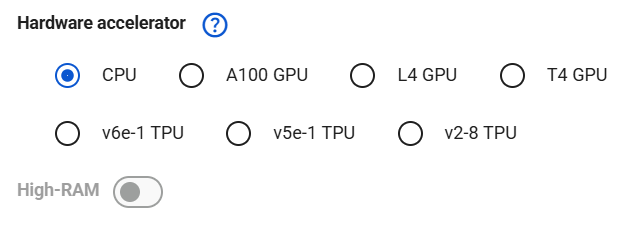

In [33]:
Image('/content/colab_pro_runtime.png') if IN_COLAB else display(Image(filename='colab_pro_runtime.png'))

## PyTorch e macOS
Se si dispone di un Mac di Apple con un **chip Apple Silicon** (come M1, M2, M3 o modelli più recenti), il codice della cella precedente va modificato con l'istruzione seguente:<br>
`device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")`

## Esercizio
Come prova confrontiamo il tempo di esecuzione ("run time") di una moltiplicazione matriciale su CPU e GPU. A quale dimensione della matrice l'esecuzione sulla GPU comincia ad essere più veloce?

In [ ]:
a = torch.rand(100,200)
print(a)
print(a.shape)
b = torch.rand(200,300)   # ovviamente le due matrici devono essere CONFORMI come dimensioni
print(b)
print(b.shape)

In [ ]:
%timeit a@b

In [ ]:
if torch.cuda.is_available():
    a, b = a.to("cuda"), b.to("cuda")
    %timeit a@b

Cioè il run time medio (di 10.000 loop) su GPU è **3-4 volte inferiore**.<br>
Analoghi risultati si ottengono eseguendo questo codice su una GPU di Google Colab.

## Training su molte GPU

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/appendix-a_compressed/12.webp" width="800px">
<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/appendix-a_compressed/13.webp" width="800px">

# sklearn Models are Not Deployment Friendly! Supercharge Them With Tensor Computations.
Vedi [qui](https://www.dailydoseofds.com/sklearn-models-are-not-deployment-friendly-supercharge-them-with-gpus-first/).